# QSAR for COX-2 potency — v2 with accessible data sources
### Direct ChEMBL REST **or** PubChem (no flaky client library)

If the previous notebook failed at the data step, the usual cause is the **`chembl_webresource_client`** package, not ChEMBL's data — it hangs, mis-caches, and often won't install cleanly. This version avoids it entirely and gives you **two independent ways to get real COX-2 IC50 data**:

- **Option A — ChEMBL REST API, called directly with `requests`.** Same gold-standard data, no client library, and you see exactly how the API works. Try this first.
- **Option B — PubChem.** A completely separate database, in case ChEMBL/EBI is blocked on your network.

Both options produce the **same standardised table** (`act` with columns `smiles`, `value_nM`), so every cell after the data step is shared and unchanged.

> **I could not test these live endpoints from where I built this.** Run the data cell, confirm it prints a non-zero row count, and check the two flagged spots (PubChem SMILES property name and units) if Option B returns nothing.


## 0 · Install
*Why:* just `requests` for the APIs, RDKit for fingerprints, scikit-learn for the model. No ChEMBL client.

In [1]:
!pip -q install requests rdkit scikit-learn pandas numpy matplotlib 2>/dev/null
import requests, io, json, time
import numpy as np, pandas as pd
print("ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 15.6 MB/s eta 0:00:00
ready


## Option A · ChEMBL REST API (direct)
*Why direct:* the REST endpoint `…/chembl/api/data/activity.json` is stable and returns JSON pages. We loop through pages with `offset` (transparent pagination) and ask only for **IC50** on **CHEMBL230** (human COX-2). No client library, nothing to hang.


In [2]:
def fetch_chembl(target="CHEMBL230", page=1000, max_records=8000, timeout=60):
    base = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
    rows, offset = [], 0
    while offset < max_records:
        params = {"target_chembl_id": target, "standard_type": "IC50",
                  "limit": page, "offset": offset}
        r = requests.get(base, params=params, timeout=timeout); r.raise_for_status()
        js = r.json(); acts = js.get("activities", [])
        if not acts: break
        rows += acts
        total = js["page_meta"]["total_count"]; offset += page
        print(f"  fetched {len(rows)}/{total}")
        if offset >= total: break
    df = pd.DataFrame(rows)
    # standardise -> smiles, value_nM  (keep exact IC50 '=' in nM only)
    df = df[(df.get("standard_units")=="nM") & (df.get("standard_relation")=="=")].copy()
    df["value_nM"] = pd.to_numeric(df["standard_value"], errors="coerce")
    df = df.rename(columns={"canonical_smiles":"smiles"})
    return df[["smiles","value_nM"]].dropna()

# act = fetch_chembl()          # <- uncomment to use Option A
# print("ChEMBL rows:", len(act))

## Option B · PubChem (independent database)
*Why/how:* PubChem's **SDQ** service powers the bioactivity tables on its website; we query it for all **IC50** rows whose protein accession is **P35354** (human COX-2). That returns CIDs + activity values; a second call maps each **CID → SMILES** via PUG-REST.

**Two spots to verify (flagged):**
1. PubChem renamed its SMILES property in 2025 — the code tries `SMILES`, then `IsomericSMILES`, then `CanonicalSMILES`.
2. PubChem activity values are commonly in **µM**; we convert µM → nM. If your table is already nM, remove the `*1000`.


In [7]:
def fetch_pubchem(accession="P35354", actname="IC50", limit=100000, timeout=180):
    q = {"select": ["cid","acname","acvalue","acqualifier"],
         "collection": "bioactivity",
         "where": {"ands": [{"protacxn": accession}, {"acname": actname}]},
         "order": ["acvalue,asc"], "start": 1, "limit": limit}
    url = "https://pubchem.ncbi.nlm.nih.gov/sdq/sdqagent.cgi"
    txt = requests.get(url, params={"infmt":"json","outfmt":"csv","query":json.dumps(q)},
                       timeout=timeout).text
    bio = pd.read_csv(io.StringIO(txt))
    print("PubChem bioactivity rows:", len(bio), "| columns:", list(bio.columns))

    # CID -> SMILES  (FLAG 1: property name changed in 2025; try several)
    cids = bio["cid"].dropna().astype(int).unique().tolist()
    smap = {}
    for i in range(0, len(cids), 150):
        chunk = ",".join(map(str, cids[i:i+150]))
        for prop in ["SMILES","IsomericSMILES","CanonicalSMILES"]:
            u = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{chunk}/property/{prop}/CSV"
            rr = requests.get(u, timeout=120)
            if rr.ok and rr.text.startswith("\"CID\"") or (rr.ok and "CID" in rr.text[:20]):
                cdf = pd.read_csv(io.StringIO(rr.text))
                scol = [c for c in cdf.columns if c != "CID"][0]
                smap.update({int(r.CID): getattr(r, scol) for r in cdf.itertuples()})
                break
        time.sleep(0.2)
    bio["smiles"] = bio["cid"].map(smap)
    bio["value_nM"] = pd.to_numeric(bio["acvalue"], errors="coerce") * 1000.0   # FLAG 2: uM -> nM
    return bio[["smiles","value_nM"]].dropna()

    act = fetch_pubchem()         # <- uncomment to use Option B
    print("PubChem rows:", len(act))

## 1 · Get the data — pick a source
Run **one** of the options below. Option A first; if it errors or returns 0 rows (network/blocked), switch to Option B. The result must be a DataFrame `act` with columns `smiles`, `value_nM`.


In [9]:
import pandas as pd # Ensure pandas is imported if not already, for pd.DataFrame

try:
    act = fetch_chembl()                 # Option A
    assert len(act) > 0
    print("Using ChEMBL. Rows:", len(act))
except Exception as e:
    print(f"ChEMBL failed ({str(e)[:80]}) -> trying PubChem")
    try:
        act = fetch_pubchem()                # Option B
        if len(act) > 0:
            print("Using PubChem. Rows:", len(act))
        else:
            print("PubChem returned no rows.")
    except Exception as pubchem_e:
        print(f"PubChem also failed ({str(pubchem_e)[:80]})")
        act = pd.DataFrame(columns=['smiles', 'value_nM']) # Ensure act is always a DataFrame
        print("Returning an empty DataFrame for 'act'. Please check API availability or data format.")

if 'act' in locals() and not act.empty:
    print("Data retrieved:")
    act.head()
else:
    print("No data was successfully retrieved to display.")

  fetched 1000/8504
  fetched 2000/8504
  fetched 3000/8504
  fetched 4000/8504
  fetched 5000/8504
  fetched 6000/8504
  fetched 7000/8504
  fetched 8000/8504
Using ChEMBL. Rows: 5946
Data retrieved:


## 2 · Clean and convert to pIC50  *(shared, source-agnostic)*
*Why pIC50:* potency spans orders of magnitude; **pIC50 = -log10(IC50 in molar) = 9 - log10(IC50_nM)** gives a tidy, roughly normal target that is linear in binding energy. Deduplicate molecules by median.


In [10]:
df = act[(act["value_nM"] > 0) & (act["value_nM"] < 1e7)].copy()
df["pIC50"] = 9 - np.log10(df["value_nM"])
df = df.groupby("smiles", as_index=False)["pIC50"].median()
print(f"clean unique molecules: {len(df)}")
print(df["pIC50"].describe().round(2))

clean unique molecules: 4211
count    4211.00
mean        6.09
std         1.21
min         2.15
25%         5.22
50%         6.07
75%         6.96
max        11.22
Name: pIC50, dtype: float64


## 3 · Featurise — Morgan/ECFP4 fingerprints
*Why:* each bit flags a local substructure, so similar molecules get similar vectors — the right input for a similarity-learning model. (Modern `MorganGenerator` API.)


In [11]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def featurise(smiles):
    X, keep = [], []
    for i, s in enumerate(smiles):
        m = Chem.MolFromSmiles(str(s))
        if m is None: continue
        arr = np.zeros((2048,), dtype=int)
        DataStructs.ConvertToNumpyArray(gen.GetFingerprint(m), arr)
        X.append(arr); keep.append(i)
    return np.array(X), keep
X, keep = featurise(df["smiles"]); y = df["pIC50"].values[keep]
print("features:", X.shape)

features: (4211, 2048)


## 4 · Train + validate (Random Forest, 5-fold CV)
*Why RF:* robust on sparse fingerprints, little tuning, hard to overfit. *Why CV:* one split can mislead.
**Caveat:** a random split lets near-twins leak across train/test and inflates R²; report a **scaffold split** for any serious claim.


CV R2 = 0.601 | RMSE = 0.761 pIC50


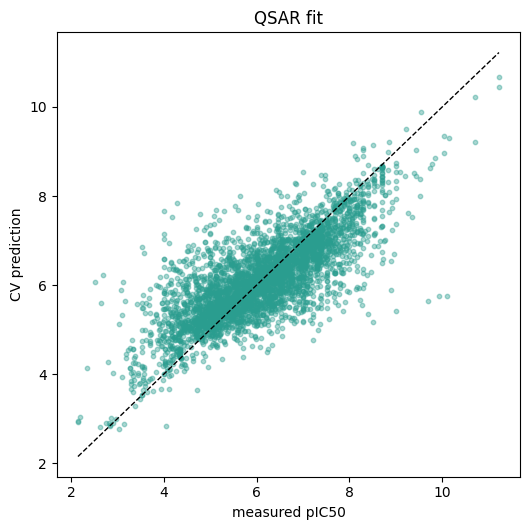

RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=0)

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
model = RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1)
y_cv = cross_val_predict(model, X, y, cv=KFold(5, shuffle=True, random_state=0))
print(f"CV R2 = {r2_score(y, y_cv):.3f} | RMSE = {mean_squared_error(y, y_cv)**0.5:.3f} pIC50")
plt.figure(figsize=(5.4,5.4)); plt.scatter(y, y_cv, s=10, alpha=0.4, color="#2a9d8f")
lim=[min(y.min(),y_cv.min()), max(y.max(),y_cv.max())]; plt.plot(lim,lim,"k--",lw=1)
plt.xlabel("measured pIC50"); plt.ylabel("CV prediction"); plt.title("QSAR fit"); plt.tight_layout(); plt.show()
model.fit(X, y)

## 5 · Applicability domain + predict your library
A prediction is only trustworthy for molecules resembling the training set. We flag each library molecule by its **max Tanimoto similarity** to training compounds (rule of thumb: < 0.3 = out of domain).


In [15]:
train_fps = [gen.GetFingerprint(Chem.MolFromSmiles(s)) for s in df["smiles"].values[keep]]
def max_sim(s):
    m = Chem.MolFromSmiles(s)
    return max(DataStructs.BulkTanimotoSimilarity(gen.GetFingerprint(m), train_fps)) if m else np.nan
try:
    lib = pd.read_csv("data/library.csv")
except FileNotFoundError:
    lib = pd.DataFrame([{"id":"FA19","name":"FA19 lead",
        "smiles":"COc1ccc(C(=O)Oc2ccc(/C=C/C(=O)O)cc2OC)cc1"}])
Xl, keepl = featurise(lib["smiles"]); lib = lib.iloc[keepl].copy()
lib["pred_pIC50"]    = model.predict(Xl).round(2)
lib["max_train_sim"] = [round(max_sim(s),2) for s in lib["smiles"]]
lib["in_domain"]     = lib["max_train_sim"] >= 0.30
lib = lib.sort_values("pred_pIC50", ascending=False)
lib.to_csv("data/qsar_predictions.csv", index=False)
print(lib[["id","name","pred_pIC50","max_train_sim","in_domain"]].to_string(index=False))

  id      name  pred_pIC50  max_train_sim  in_domain
FA19 FA19 lead        5.09           0.51       True


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Notes
- **If both options return nothing:** your network may block both EBI and NCBI; run the notebook from Colab (usually open) or a different network. As a last resort, ChEMBL also offers bulk downloads (a static `.csv`/SQLite of all activities) you can load offline.
- **Trust = the validation number.** Quote the (ideally scaffold-split) CV R²; if it's weak or FA19 is out of domain, say the QSAR is only suggestive.
- **QSAR complements docking** — a data-driven potency estimate agreeing with a physics-based pose is the strong, two-method story for your portfolio.
